In [7]:
import os
import numpy as np
import pandas as pd

file_path = './test_results_v4_io.xlsx'

df_raw = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("Unnamed:")]

In [8]:
df_raw

,model,dataset,pruning,retrain,model_type,FT_lr,FT_epoch,IOparameter,dac_res,inp_noise,...,Gmin,Gmax,fix_seed,n_rep,inf_time,.,accuracy,std,ir_drop,R_wire
0,Resnet18,CIFAR10,-,-,vanilla,-,-,S/W,NaN,NaN,...,S/W,S/W,-,-,S/W,S/W,93.070000,nan,NaN,NaN
1,Resnet18,CIFAR10,0.3,O,0.3_retrained,0.0001,50,S/W,NaN,NaN,...,S/W,S/W,-,-,S/W,S/W,92.460000,nan,NaN,NaN
2,Resnet18,CIFAR10,0.4,O,0.4_retrained,0.0001,50,S/W,NaN,NaN,...,S/W,S/W,-,-,S/W,S/W,92.810000,nan,NaN,NaN
3,Resnet18,CIFAR10,0.5,O,0.5_retrained,0.0001,50,S/W,NaN,NaN,...,S/W,S/W,-,-,S/W,S/W,92.730000,nan,NaN,NaN
4,Resnet18,CIFAR10,0.6,O,0.6_retrained,0.0001,50,S/W,NaN,NaN,...,S/W,S/W,-,-,S/W,S/W,92.550000,nan,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Resnet18,CIFAR10,-,-,vanilla,-,-,non-ideal,7bit,0.0,...,0.1,25,42,30,2592000,1 month,89.211333,0.961966,NaN,NaN
946,Resnet18,CIFAR10,-,-,vanilla,-,-,non-ideal,7bit,0.0,...,0.1,25,42,30,2592000,1 month,89.714000,0.77937,NaN,NaN
947,Resnet18,CIFAR10,-,-,vanilla,-,-,non-ideal,7bit,0.0,...,0.1,25,42,30,2592000,1 month,89.793667,0.773716,NaN,NaN
948,Resnet18,CIFAR10,-,-,vanilla,-,-,non-ideal,7bit,0.0,...,0.1,25,42,30,2592000,1 month,87.090667,1.238814,NaN,NaN


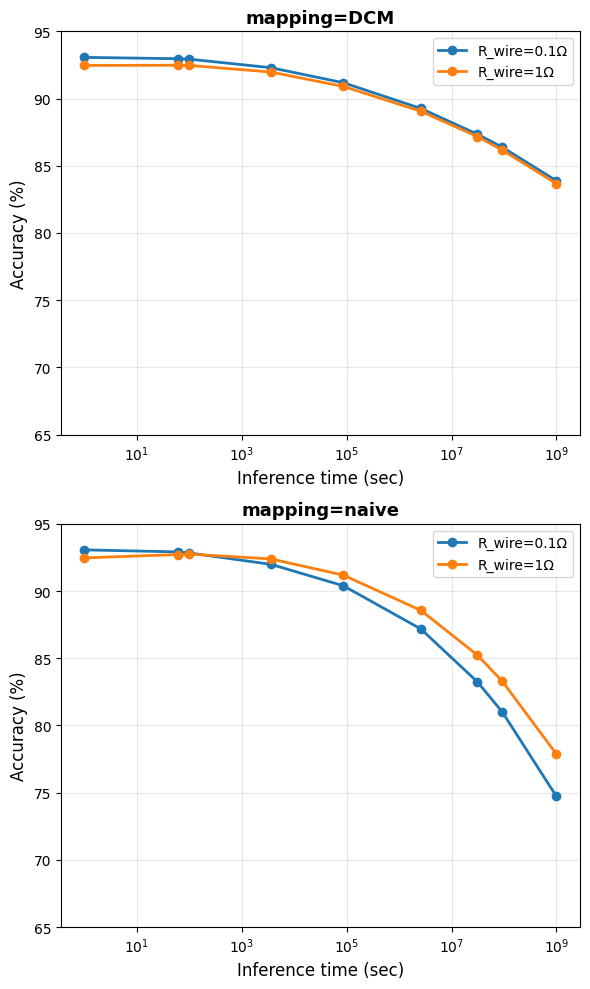

In [42]:
import matplotlib.pyplot as plt

# 1. Filter irdrop == True
df_irdrop = df_raw[df_raw['ir_drop'] == True]
df_irdrop2 = df_irdrop.copy()
df_irdrop = df_irdrop[df_irdrop['R_wire'] < 2]

# Plot 1: xaxis=inf_time, yaxis=accuracy, legend=R_wire (by mapping)
mapping_values = sorted(df_irdrop['mapping'].unique())
num_rows = len(mapping_values)

fig, axes = plt.subplots(num_rows, 1, figsize=(6, 5*num_rows))

# Handle single row case
if num_rows == 1:
    axes = [axes]

for idx, mapping_val in enumerate(mapping_values):
    df_subset = df_irdrop[df_irdrop['mapping'] == mapping_val]
    ax = axes[idx]
    
    for r_wire in sorted(df_subset['R_wire'].unique()):
        mask = df_subset['R_wire'] == r_wire
        ax.plot(df_subset[mask]['inf_time'], df_subset[mask]['accuracy'], 
                marker='o', label=f'R_wire={r_wire:g}Ω', linewidth=2, markersize=6)  
    
    ax.set_xlabel('Inference time (sec)', fontsize=12)
    ax.set_xscale('log')
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'mapping={mapping_val}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(65, 95)

plt.tight_layout()
plt.show()



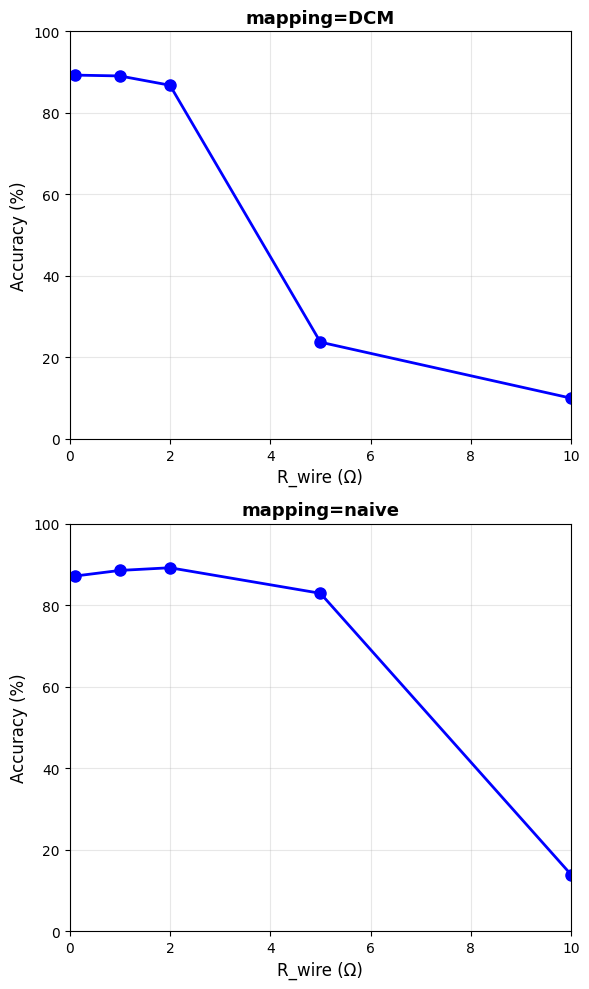

In [43]:
# Plot 2: Filter inf_time == 2592000, xaxis=R_wire, yaxis=accuracy
# Create subplots by mapping column
df_filtered = df_irdrop2[df_irdrop2['inf_time'] == 2592000]

mapping_values = sorted(df_filtered['mapping'].unique())
num_rows = len(mapping_values)

fig, axes = plt.subplots(num_rows, 1, figsize=(6, 5*num_rows))

# Handle single row case
if num_rows == 1:
    axes = [axes]

for idx, mapping_val in enumerate(mapping_values):
    df_subset = df_filtered[df_filtered['mapping'] == mapping_val]
    # Sort by R_wire
    df_subset = df_subset.sort_values('R_wire')
    ax = axes[idx]
    
    ax.plot(df_subset['R_wire'], df_subset['accuracy'], 
            marker='o', color='blue', linewidth=2, markersize=8)
    ax.set_xlabel('R_wire (Ω)', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'mapping={mapping_val}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()
